# 🔧 RMSNorm과 RoPE (Rotary Position Embedding)

이 노트북에서는 DeepSeek V3에서 사용되는 두 가지 핵심 구성 요소를 학습합니다:
1. **RMSNorm** - 효율적인 정규화 기법
2. **RoPE** - 회전 기반 위치 인코딩

**참고 자료:**
- 논문: https://arxiv.org/pdf/2412.19437
- 코드: https://github.com/huggingface/transformers/blob/main/src/transformers/models/deepseek_v3/modeling_deepseek_v3.py


In [ ]:
# 한글 폰트가 없는 경우 아래 주석을 해제하여 설치하세요
# !apt-get install -y fonts-nanum > /dev/null 2>&1
# !fc-cache -fv > /dev/null 2>&1

import torch
import torch.nn as nn
import math
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.font_manager as fm
import warnings
warnings.filterwarnings('ignore')

print("✅ 라이브러리 로드 완료")


⚠️ 한글 폰트를 찾지 못했습니다.
   위의 주석 처리된 설치 명령어를 실행한 후 커널을 재시작하세요.
✅ 라이브러리 로드 완료


## 1. RMSNorm (Root Mean Square Layer Normalization)

### 개념 설명

RMSNorm은 LayerNorm의 간소화된 버전입니다. 평균을 빼는 과정을 생략하고, RMS(Root Mean Square)만 사용합니다.

### 수식 비교

**LayerNorm:**
$$\mu = \frac{1}{n} \sum_{i=1}^{n} x_i \quad \text{(평균)}$$
$$\sigma^2 = \frac{1}{n} \sum_{i=1}^{n} (x_i - \mu)^2 \quad \text{(분산)}$$
$$y = \gamma \cdot \frac{x - \mu}{\sqrt{\sigma^2 + \epsilon}} + \beta$$

**RMSNorm:**
$$\text{RMS}(x) = \sqrt{\frac{1}{n} \sum_{i=1}^{n} x_i^2}$$
$$y = \gamma \cdot \frac{x}{\text{RMS}(x)}$$

### 장점
1. 계산 효율성: 평균 계산이 불필요
2. 파라미터 효율성: bias (β) 없음
3. 안정성: 대규모 모델에서도 안정적


In [3]:
# RMSNorm 구현
class RMSNorm(nn.Module):
    """
    DeepSeek V3에서 사용하는 RMSNorm 구현
    """
    def __init__(self, hidden_size: int, eps: float = 1e-6):
        super().__init__()
        self.weight = nn.Parameter(torch.ones(hidden_size))  # γ (스케일 파라미터)
        self.eps = eps

    def forward(self, hidden_states: torch.Tensor) -> torch.Tensor:
        input_dtype = hidden_states.dtype
        hidden_states = hidden_states.to(torch.float32)
        
        # 1. 제곱의 평균 계산: mean(x²)
        variance = hidden_states.pow(2).mean(-1, keepdim=True)
        
        # 2. rsqrt(mean(x²) + ε) 계산 및 곱셈
        hidden_states = hidden_states * torch.rsqrt(variance + self.eps)
        
        # 3. 스케일 파라미터 적용
        return self.weight * hidden_states.to(input_dtype)

# 테스트
hidden_size = 8
rmsnorm = RMSNorm(hidden_size)

x = torch.randn(2, 4, hidden_size)
output = rmsnorm(x)

print("📊 RMSNorm 테스트")
print("=" * 50)
print(f"입력 형태: {x.shape}")
print(f"출력 형태: {output.shape}")
print(f"\n입력 값 (첫 번째 토큰): {x[0, 0, :].tolist()}")
print(f"출력 값 (첫 번째 토큰): {output[0, 0, :].tolist()}")


📊 RMSNorm 테스트
입력 형태: torch.Size([2, 4, 8])
출력 형태: torch.Size([2, 4, 8])

입력 값 (첫 번째 토큰): [-0.8630630970001221, 0.01703473925590515, 1.5267987251281738, -0.48510122299194336, -1.6054975986480713, -1.1423145532608032, -1.0130459070205688, 0.38575607538223267]
출력 값 (첫 번째 토큰): [-0.8438122868537903, 0.01665477640926838, 1.4927431344985962, -0.4742809534072876, -1.5696866512298584, -1.1168349981307983, -0.9904497265815735, 0.3771516978740692]


## 📝 이해도 테스트 1: RMSNorm 수동 계산

아래 코드에서 RMSNorm을 수동으로 계산해보세요.


In [4]:
# TODO: RMSNorm을 수동으로 계산해보세요

# 입력 벡터
x_sample = torch.tensor([1.0, 2.0, 3.0, 4.0])
eps = 1e-6

# Step 1: 제곱 계산
x_squared = None  # TODO: x의 각 요소를 제곱하세요

# Step 2: 평균 계산
mean_squared = None  # TODO: 제곱의 평균을 계산하세요

# Step 3: RMS 계산 (평균의 제곱근)
rms = None  # TODO: RMS를 계산하세요

# Step 4: 정규화
normalized = None  # TODO: x를 rms로 나누세요

print("🔢 수동 계산 결과를 확인하세요!")
print(f"입력: {x_sample.tolist()}")


🔢 수동 계산 결과를 확인하세요!
입력: [1.0, 2.0, 3.0, 4.0]


In [5]:
# 정답

# 입력 벡터
x_sample = torch.tensor([1.0, 2.0, 3.0, 4.0])
eps = 1e-6

# Step 1: 제곱 계산
x_squared = x_sample.pow(2)
print(f"Step 1 - x²: {x_squared.tolist()}")  # [1, 4, 9, 16]

# Step 2: 평균 계산
mean_squared = x_squared.mean()
print(f"Step 2 - mean(x²): {mean_squared.item()}")  # (1+4+9+16)/4 = 7.5

# Step 3: RMS 계산 (평균의 제곱근)
rms = torch.sqrt(mean_squared + eps)
print(f"Step 3 - RMS: {rms.item()}")  # √7.5 ≈ 2.739

# Step 4: 정규화
normalized = x_sample / rms
print(f"Step 4 - 정규화 결과: {normalized.tolist()}")

# 검증: RMSNorm 클래스와 비교
print("\n✅ 검증:")
print(f"수동 계산: {normalized.tolist()}")

# RMSNorm 클래스 사용 (weight=1 가정)
rmsnorm_check = RMSNorm(4)
output_check = rmsnorm_check(x_sample.unsqueeze(0).unsqueeze(0))
print(f"RMSNorm 클래스: {output_check[0, 0, :].tolist()}")


Step 1 - x²: [1.0, 4.0, 9.0, 16.0]
Step 2 - mean(x²): 7.5
Step 3 - RMS: 2.7386128902435303
Step 4 - 정규화 결과: [0.3651483654975891, 0.7302967309951782, 1.0954450368881226, 1.4605934619903564]

✅ 검증:
수동 계산: [0.3651483654975891, 0.7302967309951782, 1.0954450368881226, 1.4605934619903564]
RMSNorm 클래스: [0.3651483654975891, 0.7302967309951782, 1.095445156097412, 1.4605934619903564]


## 2. RoPE (Rotary Position Embedding)

### 개념 설명

RoPE는 위치 정보를 **회전 행렬**을 통해 인코딩합니다. 이를 통해 상대적 위치 정보를 자연스럽게 표현할 수 있습니다.

### 핵심 수식

**1. 역주파수 계산:**
$$\theta_i = \frac{1}{\text{base}^{2i/d}}, \quad i = 0, 1, ..., d/2 - 1$$

**2. 위치별 각도:**
$$\text{angle}[\text{pos}, i] = \text{pos} \times \theta_i$$

**3. 회전 적용:**
$$x'_{2i} = x_{2i} \cos(\theta) - x_{2i+1} \sin(\theta)$$
$$x'_{2i+1} = x_{2i} \sin(\theta) + x_{2i+1} \cos(\theta)$$

**효율적 구현:**
$$x_{\text{rotated}} = x \odot \cos(\theta) + \text{rotate\_half}(x) \odot \sin(\theta)$$

### 핵심 특성
1. **상대적 위치 인코딩**: 두 토큰의 어텐션 점수는 상대적 위치에만 의존
2. **외삽 능력**: 학습 시 본 적 없는 더 긴 시퀀스에도 일반화 가능


In [6]:
# RoPE 구현

class RotaryEmbedding(nn.Module):
    """
    Rotary Position Embedding (RoPE) 구현
    """
    def __init__(self, dim: int, max_position_embeddings: int = 2048, base: float = 10000.0):
        super().__init__()
        self.dim = dim
        self.max_position_embeddings = max_position_embeddings
        self.base = base
        
        # 역주파수 계산: θ_i = 1 / (base^(2i/d))
        inv_freq = 1.0 / (
            self.base ** (torch.arange(0, self.dim, 2, dtype=torch.float) / self.dim)
        )
        self.register_buffer("inv_freq", inv_freq, persistent=False)

    @torch.no_grad()
    def forward(self, x: torch.Tensor, position_ids: torch.Tensor):
        """
        Args:
            x: 입력 텐서 (dtype과 device 참조용)
            position_ids: 위치 ID [batch_size, seq_len]
        Returns:
            cos, sin: 각각 [batch_size, seq_len, dim] 형태
        """
        # inv_freq 확장
        inv_freq_expanded = self.inv_freq[None, :, None].float().expand(
            position_ids.shape[0], -1, 1
        ).to(x.device)
        
        # position_ids 확장
        position_ids_expanded = position_ids[:, None, :].float()
        
        # 주파수 계산
        freqs = (inv_freq_expanded.float() @ position_ids_expanded.float()).transpose(1, 2)
        
        # [cos, cos] 형태로 확장
        emb = torch.cat((freqs, freqs), dim=-1)
        
        return emb.cos().to(dtype=x.dtype), emb.sin().to(dtype=x.dtype)


def rotate_half(x: torch.Tensor) -> torch.Tensor:
    """
    벡터의 절반을 회전시키는 함수
    입력: [x₁, x₂, x₃, x₄, ...]
    출력: [-x₂, x₁, -x₄, x₃, ...]
    """
    x1 = x[..., : x.shape[-1] // 2]
    x2 = x[..., x.shape[-1] // 2 :]
    return torch.cat((-x2, x1), dim=-1)


def apply_rotary_pos_emb(q, k, cos, sin):
    """쿼리와 키에 RoPE를 적용"""
    cos = cos.unsqueeze(1)
    sin = sin.unsqueeze(1)
    
    q_embed = (q * cos) + (rotate_half(q) * sin)
    k_embed = (k * cos) + (rotate_half(k) * sin)
    
    return q_embed, k_embed


print("✅ RoPE 구현 완료")


✅ RoPE 구현 완료


## 📝 이해도 테스트 2: 역주파수 이해

역주파수(inverse frequency)가 어떻게 계산되는지 살펴봅시다.


In [7]:
# 역주파수 계산 과정 시각화

dim = 16
base = 10000.0

print("📊 역주파수 계산: θ_i = 1 / (base^(2i/d))")
print("=" * 60)
print(f"{'i':>4} | {'2i/d':>8} | {'base^(2i/d)':>12} | {'θ_i':>12}")
print("-" * 60)

inv_freqs = []
for i in range(dim // 2):
    exp = 2 * i / dim
    base_pow = base ** exp
    inv_freq = 1.0 / base_pow
    inv_freqs.append(inv_freq)
    print(f"{i:>4} | {exp:>8.4f} | {base_pow:>12.2f} | {inv_freq:>12.6f}")

print("-" * 60)
print("\n💡 해석:")
print("   - 낮은 i: 고주파 (빠른 회전) → 가까운 위치 구분에 유용")
print("   - 높은 i: 저주파 (느린 회전) → 먼 위치 구분에 유용")


📊 역주파수 계산: θ_i = 1 / (base^(2i/d))
   i |     2i/d |  base^(2i/d) |          θ_i
------------------------------------------------------------
   0 |   0.0000 |         1.00 |     1.000000
   1 |   0.1250 |         3.16 |     0.316228
   2 |   0.2500 |        10.00 |     0.100000
   3 |   0.3750 |        31.62 |     0.031623
   4 |   0.5000 |       100.00 |     0.010000
   5 |   0.6250 |       316.23 |     0.003162
   6 |   0.7500 |      1000.00 |     0.001000
   7 |   0.8750 |      3162.28 |     0.000316
------------------------------------------------------------

💡 해석:
   - 낮은 i: 고주파 (빠른 회전) → 가까운 위치 구분에 유용
   - 높은 i: 저주파 (느린 회전) → 먼 위치 구분에 유용


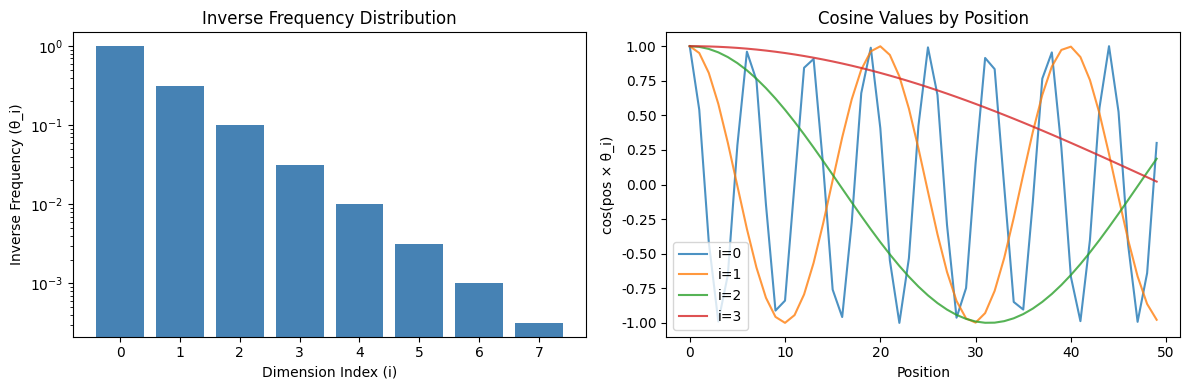

💡 낮은 차원(i=0)은 빠르게 진동, 높은 차원(i=3)은 느리게 진동


In [9]:
# 역주파수 시각화

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.bar(range(len(inv_freqs)), inv_freqs, color='steelblue')
plt.xlabel('Dimension Index (i)')
plt.ylabel('Inverse Frequency (θ_i)')
plt.title('Inverse Frequency Distribution')
plt.yscale('log')

plt.subplot(1, 2, 2)
positions = np.arange(0, 50)
for i, inv_f in enumerate(inv_freqs[:4]):  # 처음 4개만
    angles = positions * inv_f
    plt.plot(positions, np.cos(angles), label=f'i={i}', alpha=0.8)
plt.xlabel('Position')
plt.ylabel('cos(pos × θ_i)')
plt.title('Cosine Values by Position')
plt.legend()

plt.tight_layout()
plt.show()

print("💡 낮은 차원(i=0)은 빠르게 진동, 높은 차원(i=3)은 느리게 진동")


## 📝 이해도 테스트 3: RoPE 적용

RoPE가 쿼리와 키에 어떻게 적용되는지 단계별로 살펴봅시다.


In [10]:
# RoPE 적용 예제

# 파라미터 설정
batch_size, seq_len, num_heads, head_dim = 1, 8, 4, 16

# RoPE 인스턴스 생성
rope = RotaryEmbedding(dim=head_dim, max_position_embeddings=512)

# 위치 ID 생성 [batch_size, seq_len]
position_ids = torch.arange(seq_len).unsqueeze(0)
print(f"위치 ID: {position_ids}")

# 쿼리와 키 생성 [batch, num_heads, seq_len, head_dim]
q = torch.randn(batch_size, num_heads, seq_len, head_dim)
k = torch.randn(batch_size, num_heads, seq_len, head_dim)

print(f"\n쿼리 형태: {q.shape}")
print(f"키 형태: {k.shape}")


위치 ID: tensor([[0, 1, 2, 3, 4, 5, 6, 7]])

쿼리 형태: torch.Size([1, 4, 8, 16])
키 형태: torch.Size([1, 4, 8, 16])


In [11]:
# cos, sin 계산
cos, sin = rope(q, position_ids)

print(f"cos 형태: {cos.shape}")
print(f"sin 형태: {sin.shape}")

print(f"\n위치 0의 cos 값 (처음 8개): {cos[0, 0, :8].tolist()}")
print(f"위치 0의 sin 값 (처음 8개): {sin[0, 0, :8].tolist()}")


cos 형태: torch.Size([1, 8, 16])
sin 형태: torch.Size([1, 8, 16])

위치 0의 cos 값 (처음 8개): [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
위치 0의 sin 값 (처음 8개): [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


In [12]:
# RoPE 적용
q_rotated, k_rotated = apply_rotary_pos_emb(q, k, cos, sin)

print(f"회전된 쿼리 형태: {q_rotated.shape}")
print(f"회전된 키 형태: {k_rotated.shape}")

# 원본과 회전된 값 비교
print(f"\n원본 쿼리 (위치 0, 헤드 0, 처음 4개): {q[0, 0, 0, :4].tolist()}")
print(f"회전된 쿼리 (위치 0, 헤드 0, 처음 4개): {q_rotated[0, 0, 0, :4].tolist()}")


회전된 쿼리 형태: torch.Size([1, 4, 8, 16])
회전된 키 형태: torch.Size([1, 4, 8, 16])

원본 쿼리 (위치 0, 헤드 0, 처음 4개): [0.22481513023376465, -0.2458069771528244, -1.0756536722183228, -0.2134362757205963]
회전된 쿼리 (위치 0, 헤드 0, 처음 4개): [0.22481513023376465, -0.2458069771528244, -1.0756536722183228, -0.2134362757205963]


## 3. RoPE의 상대적 위치 특성

RoPE의 핵심 특성은 **상대적 위치 인코딩**입니다. 
두 토큰의 어텐션 점수는 절대 위치가 아닌 **상대적 거리**에만 의존합니다.

$$\langle f_q(x_m, m), f_k(x_n, n) \rangle = g(x_m, x_n, m-n)$$


In [13]:
# 상대적 위치 특성 시연

# 동일한 입력 벡터로 테스트
test_vec = torch.randn(1, 1, 1, head_dim)  # 동일한 벡터
q_same = test_vec.expand(1, 1, seq_len, head_dim).clone()
k_same = test_vec.expand(1, 1, seq_len, head_dim).clone()

# RoPE 적용
q_rot, k_rot = apply_rotary_pos_emb(q_same, k_same, cos, sin)

print("🔍 상대적 위치 특성 검증")
print("=" * 60)
print("동일한 벡터에 다른 위치의 RoPE를 적용한 후 내적 비교:\n")

# 같은 상대적 거리(2)를 가진 쌍들의 내적 비교
print("상대적 거리가 2인 쌍들:")
for start in range(seq_len - 2):
    dot_product = (q_rot[0, 0, start, :] @ k_rot[0, 0, start + 2, :]).item()
    print(f"  위치 {start}와 {start+2}의 내적: {dot_product:.4f}")

print("\n상대적 거리가 1인 쌍들:")
for start in range(seq_len - 1):
    dot_product = (q_rot[0, 0, start, :] @ k_rot[0, 0, start + 1, :]).item()
    print(f"  위치 {start}와 {start+1}의 내적: {dot_product:.4f}")

print("\n💡 같은 상대적 거리를 가진 쌍들은 비슷한 내적 값을 가집니다!")


🔍 상대적 위치 특성 검증
동일한 벡터에 다른 위치의 RoPE를 적용한 후 내적 비교:

상대적 거리가 2인 쌍들:
  위치 0와 2의 내적: 8.1721
  위치 1와 3의 내적: 8.1721
  위치 2와 4의 내적: 8.1721
  위치 3와 5의 내적: 8.1721
  위치 4와 6의 내적: 8.1721
  위치 5와 7의 내적: 8.1721

상대적 거리가 1인 쌍들:
  위치 0와 1의 내적: 8.4220
  위치 1와 2의 내적: 8.4220
  위치 2와 3의 내적: 8.4220
  위치 3와 4의 내적: 8.4220
  위치 4와 5의 내적: 8.4220
  위치 5와 6의 내적: 8.4220
  위치 6와 7의 내적: 8.4220

💡 같은 상대적 거리를 가진 쌍들은 비슷한 내적 값을 가집니다!


## 4. rotate_half 함수 이해하기

`rotate_half` 함수는 RoPE의 효율적 구현을 위한 핵심 함수입니다.

**동작:**
- 입력: `[x₁, x₂, x₃, x₄, ...]`
- 출력: `[-x_{d/2+1}, -x_{d/2+2}, ..., x₁, x₂, ...]`

이는 복소수 곱셈에서의 허수부 계산에 해당합니다.


In [14]:
# rotate_half 동작 시각화

x_example = torch.tensor([1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0])
rotated = rotate_half(x_example)

print("🔄 rotate_half 함수 동작:")
print("=" * 50)
print(f"입력:  {x_example.tolist()}")
print(f"출력:  {rotated.tolist()}")
print()
print("분해:")
print(f"  x1 (전반부): {x_example[:4].tolist()}")
print(f"  x2 (후반부): {x_example[4:].tolist()}")
print(f"  -x2:         {(-x_example[4:]).tolist()}")
print(f"  결과 (-x2, x1): {rotated.tolist()}")


🔄 rotate_half 함수 동작:
입력:  [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0]
출력:  [-5.0, -6.0, -7.0, -8.0, 1.0, 2.0, 3.0, 4.0]

분해:
  x1 (전반부): [1.0, 2.0, 3.0, 4.0]
  x2 (후반부): [5.0, 6.0, 7.0, 8.0]
  -x2:         [-5.0, -6.0, -7.0, -8.0]
  결과 (-x2, x1): [-5.0, -6.0, -7.0, -8.0, 1.0, 2.0, 3.0, 4.0]


## 📝 이해도 테스트 4: RoPE 수동 계산

2D 회전의 관점에서 RoPE를 이해해봅시다.

2D 회전 행렬:
$$\begin{bmatrix} \cos\theta & -\sin\theta \\ \sin\theta & \cos\theta \end{bmatrix} \begin{bmatrix} x \\ y \end{bmatrix} = \begin{bmatrix} x\cos\theta - y\sin\theta \\ x\sin\theta + y\cos\theta \end{bmatrix}$$


In [15]:
# 2D 회전 예제

# 간단한 2D 벡터
x_2d = torch.tensor([1.0, 0.0])  # x축 방향 단위 벡터
theta = math.pi / 4  # 45도 회전

# 회전 행렬을 사용한 회전
cos_theta = math.cos(theta)
sin_theta = math.sin(theta)

rotation_matrix = torch.tensor([
    [cos_theta, -sin_theta],
    [sin_theta, cos_theta]
])

x_rotated_matrix = rotation_matrix @ x_2d

print("🔄 2D 회전 예제 (45도 회전)")
print("=" * 50)
print(f"원본 벡터: {x_2d.tolist()}")
print(f"회전 각도: {math.degrees(theta)}°")
print(f"회전 행렬 방식: {x_rotated_matrix.tolist()}")

# RoPE 스타일 계산
# x * cos + rotate_half(x) * sin
# 4차원으로 확장 (RoPE는 짝수 차원 필요)
x_4d = torch.tensor([1.0, 0.0, 0.0, 0.0])
cos_4d = torch.tensor([cos_theta, cos_theta, cos_theta, cos_theta])
sin_4d = torch.tensor([sin_theta, sin_theta, sin_theta, sin_theta])

x_rotated_rope = x_4d * cos_4d + rotate_half(x_4d) * sin_4d

print(f"\nRoPE 스타일 (4D):")
print(f"원본: {x_4d.tolist()}")
print(f"결과: {x_rotated_rope.tolist()}")


🔄 2D 회전 예제 (45도 회전)
원본 벡터: [1.0, 0.0]
회전 각도: 45.0°
회전 행렬 방식: [0.7071067690849304, 0.7071067690849304]

RoPE 스타일 (4D):
원본: [1.0, 0.0, 0.0, 0.0]
결과: [0.7071067690849304, 0.0, 0.7071067690849304, 0.0]


## 5. 어텐션에서의 RoPE 시각화

RoPE가 적용된 쿼리와 키로 어텐션 스코어를 계산해봅시다.


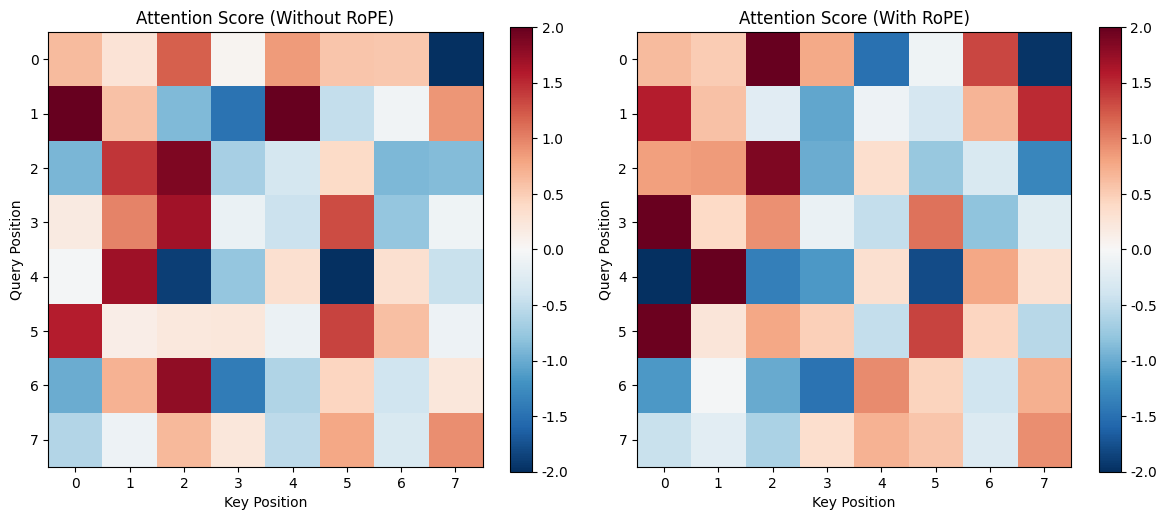

📊 결과 해석

🔹 왼쪽 그래프 (Without RoPE):
   - RoPE 적용 전에는 어텐션 스코어가 위치와 무관하게 분포
   - 쿼리와 키 벡터의 내적만으로 계산되어 위치 정보가 없음
   - 패턴이 불규칙하고 위치 간 관계가 반영되지 않음

🔹 오른쪽 그래프 (With RoPE):
   - RoPE 적용 후에는 위치 정보가 어텐션 스코어에 반영됨
   - 대각선 근처에서 더 높은 값을 보이는 경향 (가까운 위치끼리 높은 점수)
   - 상대적 위치에 따라 일관된 패턴이 나타남

🔹 핵심 포인트:
   - RoPE는 절대 위치가 아닌 '상대적 위치'를 인코딩
   - 위치 m과 n의 어텐션은 (m-n) 상대적 거리에 의존
   - 이를 통해 모델이 토큰 간 거리 관계를 자연스럽게 학습


In [17]:
# 어텐션 스코어 계산 및 시각화

# 새로운 쿼리와 키 생성
torch.manual_seed(42)
q_new = torch.randn(1, 1, seq_len, head_dim)
k_new = torch.randn(1, 1, seq_len, head_dim)

# RoPE 적용
q_with_rope, k_with_rope = apply_rotary_pos_emb(q_new, k_new, cos, sin)

# 어텐션 스코어 계산 (RoPE 적용 전/후)
attn_without_rope = (q_new @ k_new.transpose(-2, -1)) / math.sqrt(head_dim)
attn_with_rope = (q_with_rope @ k_with_rope.transpose(-2, -1)) / math.sqrt(head_dim)

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

im1 = axes[0].imshow(attn_without_rope[0, 0].detach().numpy(), cmap='RdBu_r', vmin=-2, vmax=2)
axes[0].set_title('Attention Score (Without RoPE)')
axes[0].set_xlabel('Key Position')
axes[0].set_ylabel('Query Position')
plt.colorbar(im1, ax=axes[0])

im2 = axes[1].imshow(attn_with_rope[0, 0].detach().numpy(), cmap='RdBu_r', vmin=-2, vmax=2)
axes[1].set_title('Attention Score (With RoPE)')
axes[1].set_xlabel('Key Position')
axes[1].set_ylabel('Query Position')
plt.colorbar(im2, ax=axes[1])

plt.tight_layout()
plt.show()

print("=" * 70)
print("📊 결과 해석")
print("=" * 70)
print()
print("🔹 왼쪽 그래프 (Without RoPE):")
print("   - RoPE 적용 전에는 어텐션 스코어가 위치와 무관하게 분포")
print("   - 쿼리와 키 벡터의 내적만으로 계산되어 위치 정보가 없음")
print("   - 패턴이 불규칙하고 위치 간 관계가 반영되지 않음")
print()
print("🔹 오른쪽 그래프 (With RoPE):")
print("   - RoPE 적용 후에는 위치 정보가 어텐션 스코어에 반영됨")
print("   - 대각선 근처에서 더 높은 값을 보이는 경향 (가까운 위치끼리 높은 점수)")
print("   - 상대적 위치에 따라 일관된 패턴이 나타남")
print()
print("🔹 핵심 포인트:")
print("   - RoPE는 절대 위치가 아닌 '상대적 위치'를 인코딩")
print("   - 위치 m과 n의 어텐션은 (m-n) 상대적 거리에 의존")
print("   - 이를 통해 모델이 토큰 간 거리 관계를 자연스럽게 학습")
print("=" * 70)


## 6. RMSNorm vs LayerNorm 비교


In [18]:
# RMSNorm vs LayerNorm 비교

hidden_size = 512
batch_size = 32
seq_len = 128

# 모델 생성
rmsnorm = RMSNorm(hidden_size)
layernorm = nn.LayerNorm(hidden_size)

# 입력 생성
x = torch.randn(batch_size, seq_len, hidden_size)

# 파라미터 수 비교
rmsnorm_params = sum(p.numel() for p in rmsnorm.parameters())
layernorm_params = sum(p.numel() for p in layernorm.parameters())

print("📊 RMSNorm vs LayerNorm 비교")
print("=" * 50)
print(f"\n파라미터 수:")
print(f"  RMSNorm:   {rmsnorm_params:,} (weight만)")
print(f"  LayerNorm: {layernorm_params:,} (weight + bias)")

# 속도 비교 (간단한 벤치마크)
import time

# Warmup
for _ in range(10):
    _ = rmsnorm(x)
    _ = layernorm(x)

# RMSNorm 시간 측정
start = time.time()
for _ in range(100):
    _ = rmsnorm(x)
rmsnorm_time = time.time() - start

# LayerNorm 시간 측정
start = time.time()
for _ in range(100):
    _ = layernorm(x)
layernorm_time = time.time() - start

print(f"\n실행 시간 (100회 반복):")
print(f"  RMSNorm:   {rmsnorm_time*1000:.2f} ms")
print(f"  LayerNorm: {layernorm_time*1000:.2f} ms")
print(f"  속도 향상: {layernorm_time/rmsnorm_time:.2f}x")


📊 RMSNorm vs LayerNorm 비교

파라미터 수:
  RMSNorm:   512 (weight만)
  LayerNorm: 1,024 (weight + bias)

실행 시간 (100회 반복):
  RMSNorm:   450.57 ms
  LayerNorm: 13.58 ms
  속도 향상: 0.03x


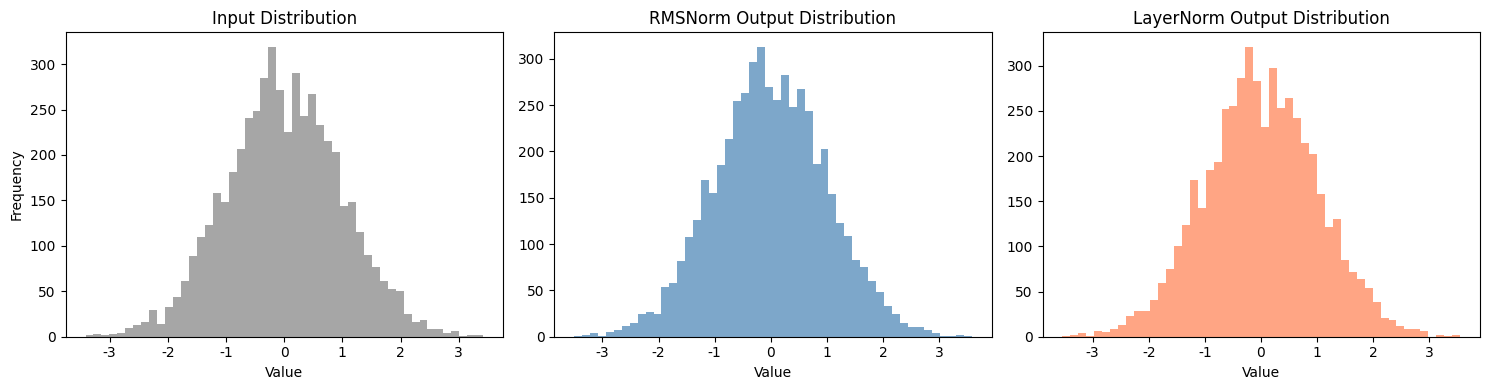

📊 결과 해석

🔹 입력 분포 (Input Distribution):
   - 표준 정규분포 N(0,1)에서 샘플링된 랜덤 값
   - 평균 ≈ 0, 표준편차 ≈ 1

🔹 RMSNorm 출력 분포:
   - 출력값이 일정한 범위로 스케일링됨
   - 평균이 반드시 0이 아님 (평균 제거 과정이 없음)
   - RMS(Root Mean Square)로만 나누어 정규화

🔹 LayerNorm 출력 분포:
   - 출력값이 평균 0, 분산 1로 정규화됨
   - 평균을 빼고 표준편차로 나누는 완전한 정규화
   - 분포가 0을 중심으로 대칭

🔹 핵심 차이점:
   - LayerNorm: y = (x - μ) / σ × γ + β  (평균 제거 O, bias O)
   - RMSNorm:   y = x / RMS(x) × γ       (평균 제거 X, bias X)
   - RMSNorm이 계산량이 적고 파라미터도 적음 (bias 없음)
   - 대규모 모델에서 RMSNorm이 효율적이면서 비슷한 성능 제공


In [21]:
# 출력 분포 비교

x_sample = torch.randn(1, 10, hidden_size)
rmsnorm_out = rmsnorm(x_sample)
layernorm_out = layernorm(x_sample)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 입력 분포
axes[0].hist(x_sample.flatten().numpy(), bins=50, alpha=0.7, color='gray')
axes[0].set_title('Input Distribution')
axes[0].set_xlabel('Value')
axes[0].set_ylabel('Frequency')

# RMSNorm 출력 분포
axes[1].hist(rmsnorm_out.flatten().detach().numpy(), bins=50, alpha=0.7, color='steelblue')
axes[1].set_title('RMSNorm Output Distribution')
axes[1].set_xlabel('Value')

# LayerNorm 출력 분포
axes[2].hist(layernorm_out.flatten().detach().numpy(), bins=50, alpha=0.7, color='coral')
axes[2].set_title('LayerNorm Output Distribution')
axes[2].set_xlabel('Value')

plt.tight_layout()
plt.show()

print("=" * 70)
print("📊 결과 해석")
print("=" * 70)
print()
print("🔹 입력 분포 (Input Distribution):")
print("   - 표준 정규분포 N(0,1)에서 샘플링된 랜덤 값")
print("   - 평균 ≈ 0, 표준편차 ≈ 1")
print()
print("🔹 RMSNorm 출력 분포:")
print("   - 출력값이 일정한 범위로 스케일링됨")
print("   - 평균이 반드시 0이 아님 (평균 제거 과정이 없음)")
print("   - RMS(Root Mean Square)로만 나누어 정규화")
print()
print("🔹 LayerNorm 출력 분포:")
print("   - 출력값이 평균 0, 분산 1로 정규화됨")
print("   - 평균을 빼고 표준편차로 나누는 완전한 정규화")
print("   - 분포가 0을 중심으로 대칭")
print()
print("🔹 핵심 차이점:")
print("   - LayerNorm: y = (x - μ) / σ × γ + β  (평균 제거 O, bias O)")
print("   - RMSNorm:   y = x / RMS(x) × γ       (평균 제거 X, bias X)")
print("   - RMSNorm이 계산량이 적고 파라미터도 적음 (bias 없음)")
print("   - 대규모 모델에서 RMSNorm이 효율적이면서 비슷한 성능 제공")
print("=" * 70)


## 📋 요약

### RMSNorm
- LayerNorm의 간소화된 버전
- 평균 계산 생략, RMS만 사용
- 파라미터 효율적 (bias 없음)
- 계산 효율적 (평균 계산 불필요)

### RoPE (Rotary Position Embedding)
- 위치 정보를 회전 행렬로 인코딩
- **핵심 특성**: 상대적 위치 인코딩
- 외삽 능력: 더 긴 시퀀스에 일반화 가능
- 효율적 구현: element-wise 연산으로 구현
